In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from LearningAlgorithms import ClassificationAlgorithms
import seaborn as sns
import itertools
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Plot settings
plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["lines.linewidth"] = 2

In [2]:
df = pd.read_pickle("../../data/interim/03_feature_eng.pkl")
df

,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,participants,label,Category,set,...,gyr_r_pse,gyr_r_freq_0.0_Hz_ws_14,gyr_r_freq_0.357_Hz_ws_14,gyr_r_freq_0.714_Hz_ws_14,gyr_r_freq_1.071_Hz_ws_14,gyr_r_freq_1.429_Hz_ws_14,gyr_r_freq_1.786_Hz_ws_14,gyr_r_freq_2.143_Hz_ws_14,gyr_r_freq_2.5_Hz_ws_14,cluster
epoch (ms),,,,,,,,,,,,,,,,,,,,,
2019-01-11 15:08:08.000,-0.172350,0.909033,-0.168556,-27.895242,-10.831760,26.285743,B,bench,heavy,69,...,0.404506,241.915837,-32.414519,17.800054,-7.090627,-23.559585,15.300362,-56.937517,-9.887314,1
2019-01-11 15:08:08.400,-0.024777,0.860474,-0.059254,-2.040040,-1.316930,1.986210,B,bench,heavy,69,...,0.376805,266.641927,-45.027971,-65.743054,-12.016695,8.716330,14.278175,5.797033,-2.207473,1
2019-01-11 15:08:08.800,-0.063378,0.997048,-0.033869,1.164754,-1.844231,-1.240332,B,bench,heavy,69,...,0.508919,262.078311,-56.234625,-30.091473,3.458370,-13.917311,-48.217504,42.767778,-11.602442,1
2019-01-11 15:08:09.200,-0.044993,0.971809,-0.038011,2.469483,-3.482648,3.563210,B,bench,heavy,69,...,0.492961,256.245567,-31.989318,69.348370,3.624009,17.424045,36.328368,26.990522,-9.999852,1
2019-01-11 15:08:09.600,-0.046925,0.911220,-0.056463,8.471911,4.745072,-8.708681,B,bench,heavy,69,...,0.363189,214.663711,-12.227055,13.687545,10.833066,6.326124,25.453064,-35.551747,-33.538487,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019-01-20 17:33:26.200,0.063910,-0.952114,0.107673,-38.792016,8.810964,14.997831,E,row,medium,56,...,0.350704,368.429928,29.216316,-57.045603,10.239165,-47.609218,-37.827325,-17.620149,-36.551825,3
2019-01-20 17:33:26.600,-0.024266,-1.193314,-0.109309,-2.783290,-1.783932,6.232364,E,row,medium,56,...,0.324461,379.719977,39.879652,-21.517667,-13.542762,27.460451,82.477003,22.715838,9.757813,0
2019-01-20 17:33:27.000,-0.043276,-0.988153,-0.062545,2.032956,-4.019557,0.196986,E,row,medium,56,...,0.238607,319.521621,-34.907878,31.861740,9.784884,1.149502,-51.406834,-1.543486,0.948401,0


In [4]:
# Create a trainging and Test data set

df_train = df.drop(["participants","set","Category"], axis=1)

X = df_train.drop("label",axis=1)
y = df_train["label"]

In [6]:
#Spliting the test train data

X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, test_size=0.25, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2901, 117)
(967, 117)
(2901,)
(967,)


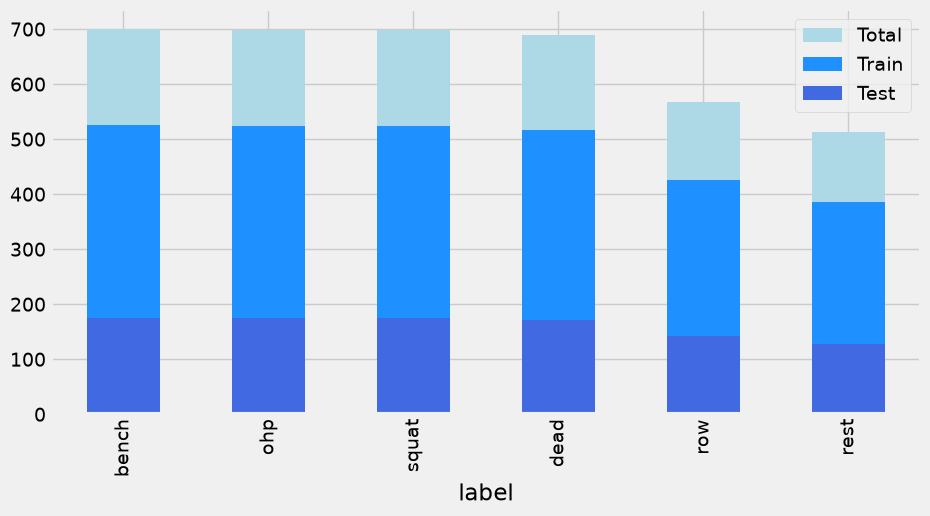

In [9]:
# Ploting the training and test data

fig, ax = plt.subplots(figsize =(10,5))
df_train["label"].value_counts().plot(kind="bar", ax=ax, color="lightblue", label="Total")

y_train.value_counts().plot(kind="bar", ax=ax, color="dodgerblue", label="Train")
y_test.value_counts().plot(kind="bar", ax=ax, color="royalblue", label="Test")

plt.legend()
plt.show()

In [16]:
# Spliting Features subset

basic_features = ["acc_x","acc_y","acc_z","gyr_x","gyr_y","gyr_z"]
square_features = ["acc_r", "gyr_r"]
pca_features = ["pca_1","pca_2","pca_3"]
time_features = [f for f in df_train.columns if "_temp_" in f]
frequency_features = [f for f in df_train.columns if ("_freq" in f) or ("_pse" in f)]
cluster_features = ["cluster"]


print("Basic Features:", len(basic_features))
print("Square Features:", len(square_features))
print("PCA Features:", len(pca_features))
print("Time Features:", len(time_features))
print("Frequency Features:", len(frequency_features))
print("Cluster Features:", len(cluster_features))

Basic Features: 6
Square Features: 2
PCA Features: 3
Time Features: 16
Frequency Features: 88
Cluster Features: 1


In [18]:
#Creating byfircation to check in future
feature_set_1 = list(set(basic_features)) 
feature_set_2 = list(set(basic_features + square_features + pca_features))
feature_set_3 = list(set(feature_set_2 + time_features))
feature_set_4 = list(set(feature_set_3 + frequency_features + cluster_features))

# Starting with model selection

In [19]:
# Performaing forward feature selection using simple decision tree

# We are using a custom model to select features for best predection

learner = ClassificationAlgorithms()

max_features = 10

selected_features, ordered_features, ordered_scores = learner.forward_selection(max_features, X_train, y_train)

0
1
2
3
4
5
6
7
8
9


plt.figure(figsize=(5,5))
plt.plot(np.arange(1, max_features + 1, 1), ordered_scores)
plt.show()

In [28]:
print(list(ordered_scores))
print(selected_features)

[0.8872802481902792, 0.9758703895208549, 0.9975870389520854, 0.9993105825577387, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
['pca_1', 'duration', 'acc_z_freq_0.0_Hz_ws_14', 'gyr_r_freq_weighted', 'acc_y_freq_0.357_Hz_ws_14', 'gyr_r_max_freq', 'gyr_y_freq_1.071_Hz_ws_14', 'acc_z_freq_1.786_Hz_ws_14', 'acc_r_pse', 'gyr_y_max_freq']


In [29]:
selected_features = ['pca_1', 
                     'duration',
                     'acc_z_freq_0.0_Hz_ws_14',
                     'gyr_r_freq_weighted', 
                     'acc_y_freq_0.357_Hz_ws_14',
                     'gyr_r_max_freq',
                     'gyr_y_freq_1.071_Hz_ws_14',
                     'acc_z_freq_1.786_Hz_ws_14', 
                     'acc_r_pse',
                     'gyr_y_max_freq']

## Grid Search

Grid Search to select optimal Hyperparameter. We will perform grid search of the most important parameters validate them a 5 fold cross validation on the trainging set.

Example:
        {
        "min_samples_leaf" : [2,10,50,100,200],
        "n_estimators" : [10,50,100],
        "criterion" : ["gini", "entropy"]
        }

        rf = GridSearchCV( 
                           RandmForestClassifier(), tuned_parameters, cv=5, scoring ="accuracy" )


In [32]:
# Grid Search for best hyperparameters and model selections

#preparing data for model as per model requirment, so we are initaling in starting

possible_feature_sets = [feature_set_1, feature_set_2, feature_set_3, feature_set_4, selected_features]

feature_names = ["feature_set_1", "feature_set_2", "feature_set_3", "feature_set_4", "selected_features"]

iterations = 1
score_df = pd.DataFrame()


### Grid Search code from github use for further use

In [33]:

for i, f in zip(range(len(possible_feature_sets)), feature_names):
    print("Feature set:", i)
    selected_train_X = X_train[possible_feature_sets[i]]
    selected_test_X = X_test[possible_feature_sets[i]]

    # First run non deterministic classifiers to average their score.
    performance_test_nn = 0
    performance_test_rf = 0

    for it in range(0, iterations):
        print("\tTraining neural network,", it)
        (
            class_train_y,
            class_test_y,
            class_train_prob_y,
            class_test_prob_y,
        ) = learner.feedforward_neural_network(
            selected_train_X,
            y_train,
            selected_test_X,
            gridsearch=False,
        )
        performance_test_nn += accuracy_score(y_test, class_test_y)

        print("\tTraining random forest,", it)
        (
            class_train_y,
            class_test_y,
            class_train_prob_y,
            class_test_prob_y,
        ) = learner.random_forest(
            selected_train_X, y_train, selected_test_X, gridsearch=True
        )
        performance_test_rf += accuracy_score(y_test, class_test_y)

    performance_test_nn = performance_test_nn / iterations
    performance_test_rf = performance_test_rf / iterations

    # And we run our deterministic classifiers:
    print("\tTraining KNN")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.k_nearest_neighbor(
        selected_train_X, y_train, selected_test_X, gridsearch=True
    )
    performance_test_knn = accuracy_score(y_test, class_test_y)

    print("\tTraining decision tree")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.decision_tree(
        selected_train_X, y_train, selected_test_X, gridsearch=True
    )
    performance_test_dt = accuracy_score(y_test, class_test_y)

    print("\tTraining naive bayes")
    (
        class_train_y,
        class_test_y,
        class_train_prob_y,
        class_test_prob_y,
    ) = learner.naive_bayes(selected_train_X, y_train, selected_test_X)

    performance_test_nb = accuracy_score(y_test, class_test_y)

    # Save results to dataframe
    models = ["NN", "RF", "KNN", "DT", "NB"]
    new_scores = pd.DataFrame(
        {
            "model": models,
            "feature_set": f,
            "accuracy": [
                performance_test_nn,
                performance_test_rf,
                performance_test_knn,
                performance_test_dt,
                performance_test_nb,
            ],
        }
    )
    score_df = pd.concat([score_df, new_scores])

Feature set: 0
	Training neural network, 0
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
Feature set: 1
	Training neural network, 0
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
Feature set: 2
	Training neural network, 0
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
Feature set: 3
	Training neural network, 0
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes
Feature set: 4
	Training neural network, 0
	Training random forest, 0
	Training KNN
	Training decision tree
	Training naive bayes


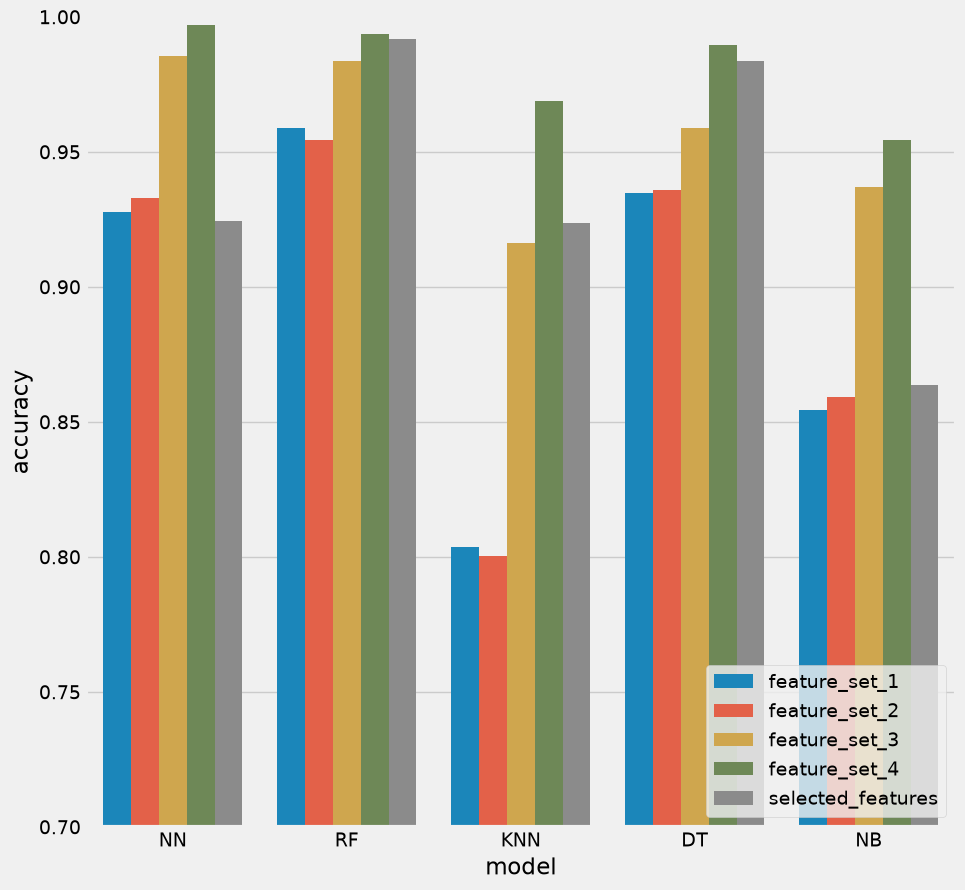

In [37]:
# Create a grouped bar plot to compare the result

score_df.sort_values(by = "accuracy", ascending=False )

plt.figure(figsize=(10,10))
sns.barplot(x="model", y="accuracy", hue="feature_set", data=score_df)
plt.xlabel("model")
plt.ylabel("accuracy")
plt.ylim(0.7, 1)
plt.legend(loc="lower right")
plt.show()

In [38]:
# Select best model and evaluate results (random forest)

print("Training random forest")
(
    class_train_y,
    class_test_y,
    class_train_prob_y,
    class_test_prob_y 
                    )  = learner.random_forest(
                        X_train[feature_set_4], y_train, X_test[feature_set_4], 
                        gridsearch=True)


Training random forest


In [42]:
#Accuracy Score
accuracy = accuracy_score(y_test, class_test_y)
print(accuracy)

0.9948293691830403


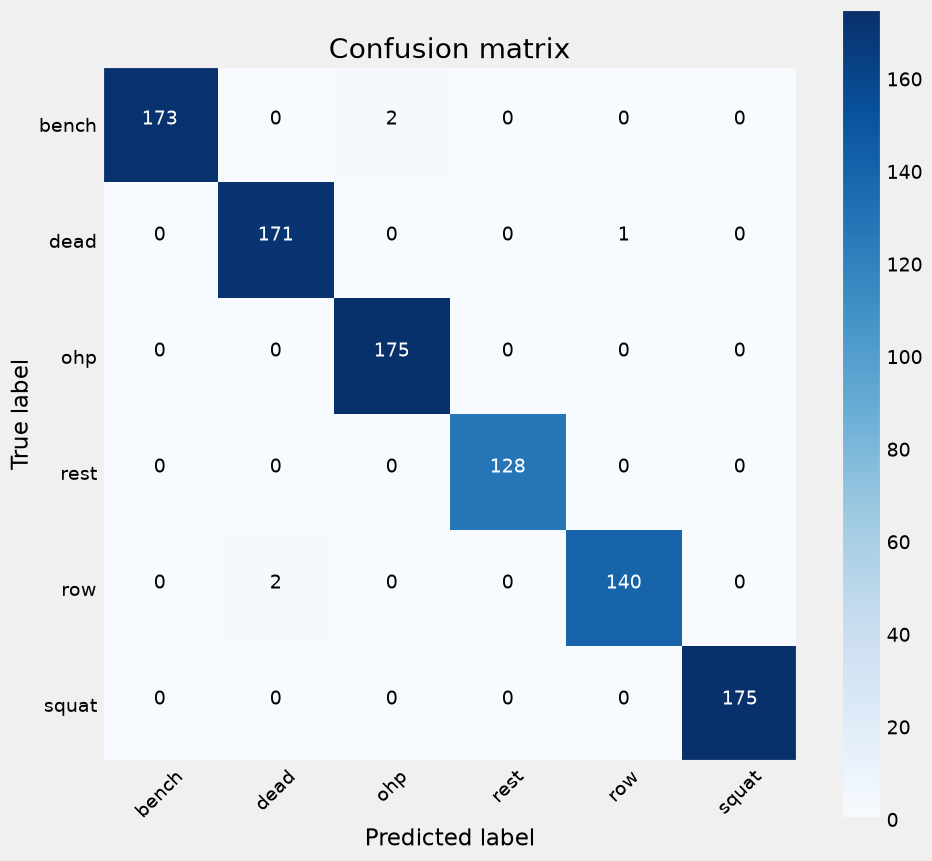

In [44]:
#confusion metrix

classes = class_test_prob_y.columns
cm = confusion_matrix(y_test, class_test_y, labels=classes)

# create confusion matrix for cm
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()



# Selecting Data on bases of Pariticipants

Till now all the data have been seperated and been trained on, But there is a chance that on individual parttern has came in traing and testing data, giving duplicate data, which increasing the accuracy, As this is exercise data with 5 pariticipants with similar exercise.

one can perform same number for training and testing in the same window. That is half worng and will genrate overfitting result

In [54]:
participant_df = df.drop(["set", "Category"], axis=1)

X_train = participant_df[participant_df["participants"] != "A"].drop("label", axis = 1)
y_train = participant_df[participant_df["participants"] != "A"]["label"]


#test data for only "A"
X_test = participant_df[participant_df["participants"] == "A"].drop("label", axis = 1)
y_test = participant_df[participant_df["participants"] == "A"]["label"]

#droping the unwanted col
X_train = X_train.drop(["participants"], axis=1)
X_test = X_test.drop(["participants"], axis=1)

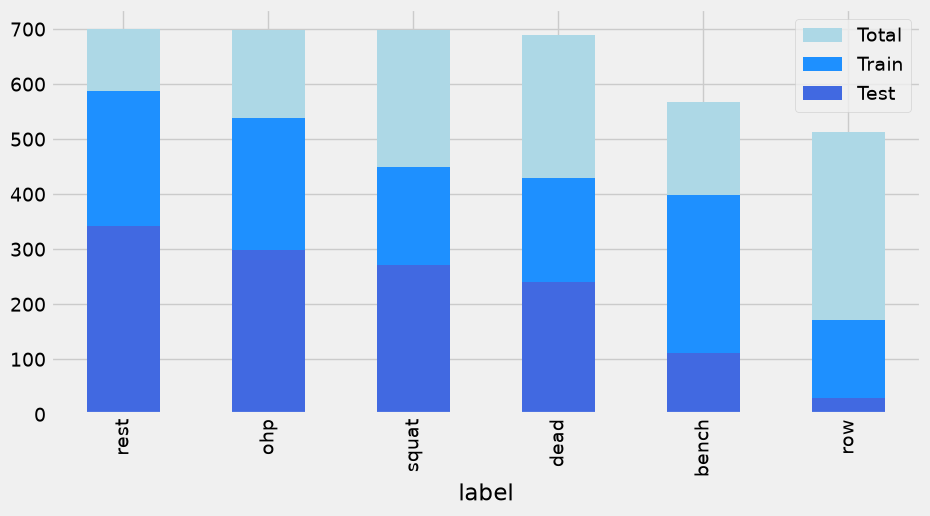

In [56]:
#plotting on x_train and X_test 

fig, ax = plt.subplots(figsize =(10,5))
df_train["label"].value_counts().plot(kind="bar", ax=ax, color="lightblue", label="Total")

y_train.value_counts().plot(kind="bar", ax=ax, color="dodgerblue", label="Train")
y_test.value_counts().plot(kind="bar", ax=ax, color="royalblue", label="Test")

plt.legend()
plt.show()

Training random forest
0.9845201238390093


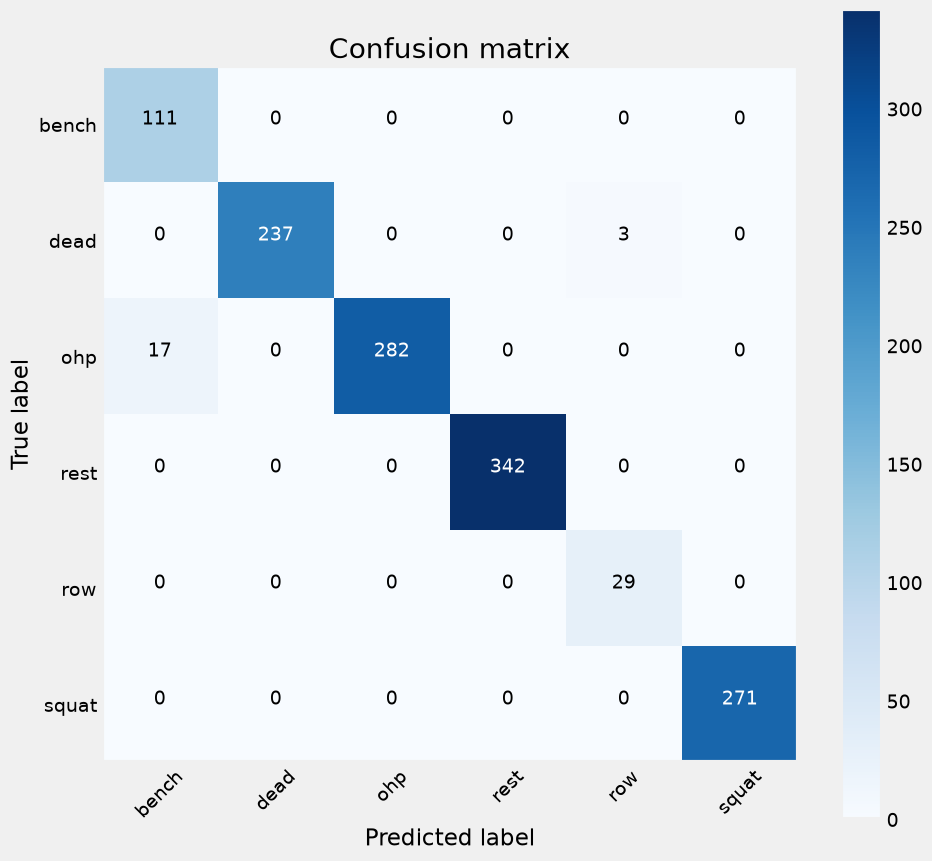

In [57]:
# Select best model and evaluate results (random forest)

print("Training random forest")
(
    class_train_y,
    class_test_y,
    class_train_prob_y,
    class_test_prob_y 
                    )  = learner.random_forest(
                        X_train[feature_set_4], y_train, X_test[feature_set_4], 
                        gridsearch=True)

#Accuracy Score
accuracy = accuracy_score(y_test, class_test_y)
print(accuracy)

#confusion metrix

classes = class_test_prob_y.columns
cm = confusion_matrix(y_test, class_test_y, labels=classes)

# create confusion matrix for cm
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

Training Netural Networ


/home/malik/.local/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/malik/.local/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/malik/.local/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/malik/.local/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/malik/.local/lib/python3.14/site-packages/

0.8521671826625387


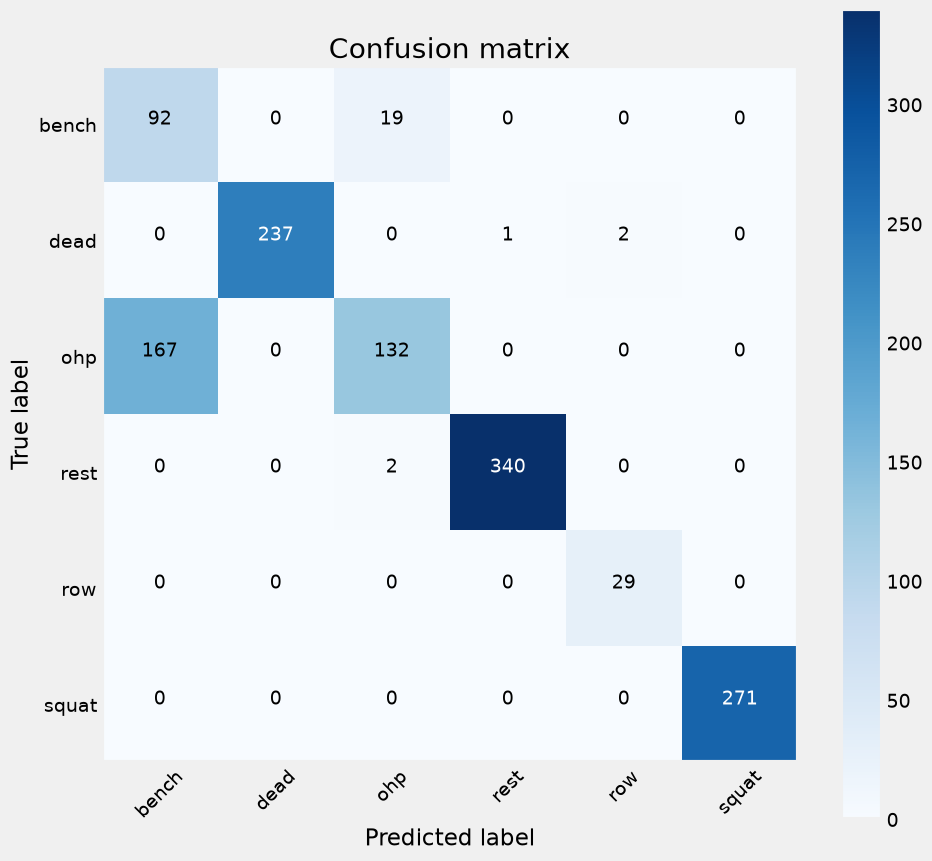

In [59]:
# Trying new Model Netural Network

print("Training Netural Networ")
(
    class_train_y,
    class_test_y,
    class_train_prob_y,
    class_test_prob_y 
                    )  = learner.feedforward_neural_network(
                        X_train[selected_features], y_train, X_test[selected_features], 
                        gridsearch=True)

#Accuracy Score
accuracy = accuracy_score(y_test, class_test_y)
print(accuracy)

#confusion metrix

classes = class_test_prob_y.columns
cm = confusion_matrix(y_test, class_test_y, labels=classes)

# create confusion matrix for cm
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

Training Netural Network
0.9907120743034056


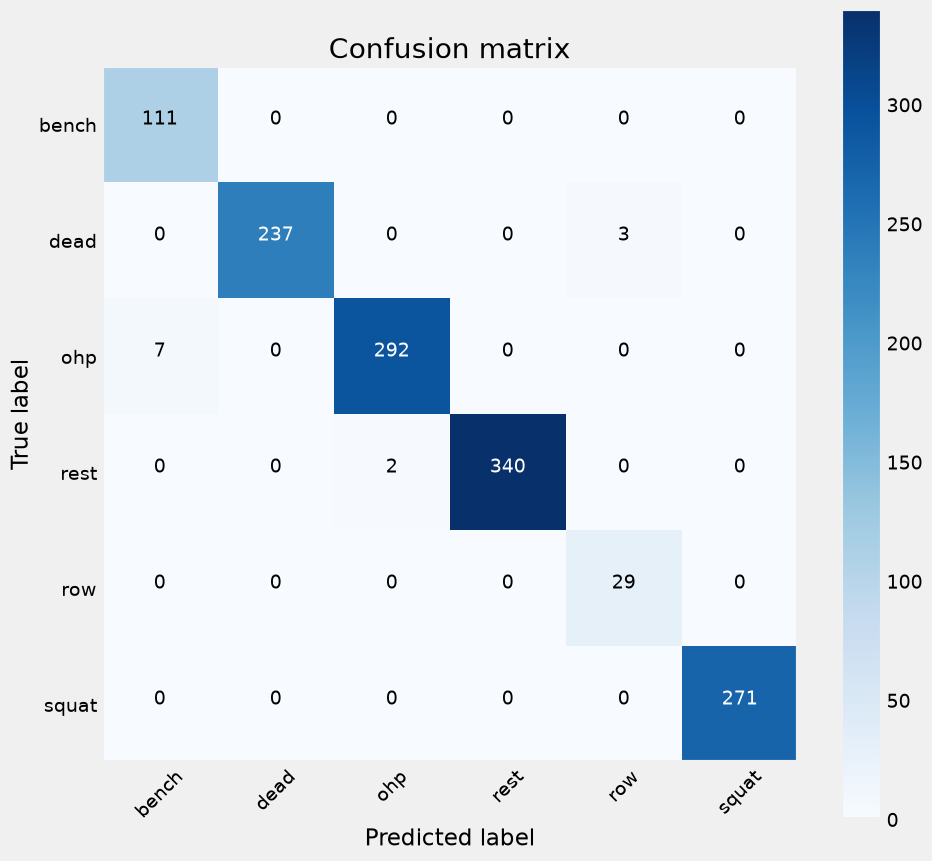

In [63]:
#updating the selected features and Netural network

selected_features = [
    "acc_z_freq_0.0_Hz_ws_14",
    "acc_x_freq_0.0_Hz_ws_14",
    "gyr_r_freq_0.0_Hz_ws_14",
    "acc_z",
    "pca_1",
    "acc_r_temp_std_ws_5",
    "gyr_y_temp_std_ws_5",
    "acc_z_freq_1.429_Hz_ws_14",
    "gyr_z_freq_1.071_Hz_ws_14",
    "gyr_x_temp_std_ws_5",
]


# Trying new Model Netural Network

print("Training Netural Network")
(
    class_train_y,
    class_test_y,
    class_train_prob_y,
    class_test_prob_y 
                    )  = learner.feedforward_neural_network(
                        X_train[feature_set_4], y_train, X_test[feature_set_4], 
                        gridsearch=False)

#Accuracy Score
accuracy = accuracy_score(y_test, class_test_y)
print(accuracy)

#confusion metrix

classes = class_test_prob_y.columns
cm = confusion_matrix(y_test, class_test_y, labels=classes)

# create confusion matrix for cm
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion matrix")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        format(cm[i, j]),
        horizontalalignment="center",
        color="white" if cm[i, j] > thresh else "black",
    )
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.grid(False)
plt.show()

# Solution

- We have to check multiple features and accuracy, multiple time to get the better result.
- Try other ways also to get more better result like (**XGboost or pytorch**)